# ML: Non-Linear Regression — Exponential

When `y` grows by a *fraction* of itself each step rather than by a fixed amount, the relationship is exponential. Compound interest, population growth, viral spread — and home appreciation — all follow this shape.

## Theory
- https://en.wikipedia.org/wiki/Exponential_growth

## Equation
`y = a · e^(r · x)`

**Trick:** take `ln(y)` of the *target*, then fit a regular linear regression on `(x, ln(y))`. Recover `a = exp(intercept)` and `r = slope`. Same trick as logarithmic, but applied to the target instead of the input.

## Problem Statement — years held vs property value

A starter home worth $400k that appreciates at ~6 % per year compounds:

`V(t) = V₀ · e^(r · t)` with `V₀ ≈ 400` and `r ≈ ln(1.06) ≈ 0.058`.

After 30 years it's worth ~$2.3M (a real-estate cliché for a reason).

| years | value ($k) |
| :---: | :--------: |
| 0   | 400  |
| 2   | 450  |
| 5   | 535  |
| 8   | 640  |
| 12  | 815  |
| 15  | 970  |
| 18  | 1160 |
| 22  | 1465 |
| 25  | 1720 |
| 30  | 2300 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
data = {
    'years': [0, 2, 5, 8, 12, 15, 18, 22, 25, 30],
    'value': [400, 450, 535, 640, 815, 970, 1160, 1465, 1720, 2300],
}
test = {'years': [3, 10, 20, 28]}

df = pd.DataFrame(data)
df

,years,value
0,0,400
1,2,450
2,5,535
3,8,640
4,12,815
5,15,970
6,18,1160
7,22,1465
8,25,1720
9,30,2300


Text(0.5, 1.0, 'Compound appreciation — exponential growth')

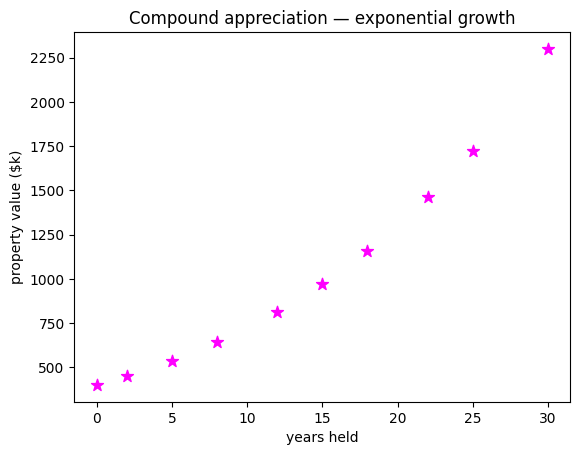

In [3]:
plt.scatter(df.years, df.value, color='magenta', marker='*', s=80)
plt.xlabel('years held')
plt.ylabel('property value ($k)')
plt.title('Compound appreciation — exponential growth')

Transform the target — fit a straight line on `(years, ln(value))`, then exponentiate the intercept to recover `a`.

In [4]:
ln_value = np.log(df['value'])
reg = LinearRegression().fit(df[['years']].values, ln_value)

r = reg.coef_[0]
a = float(np.exp(reg.intercept_))
print(f'fit: value = {a:.4f} * exp({r:.6f} * years)')
print(f'     implied annual appreciation: {(np.exp(r) - 1) * 100:.2f}%')

fit: value = 401.3371 * exp(0.058492 * years)
     implied annual appreciation: 6.02%


In [5]:
tst = pd.DataFrame(test)
tst['value'] = a * np.exp(r * tst['years'])
tst

,years,value
0,3,478.319384
1,10,720.340960
2,20,1292.905748
3,28,2064.381085


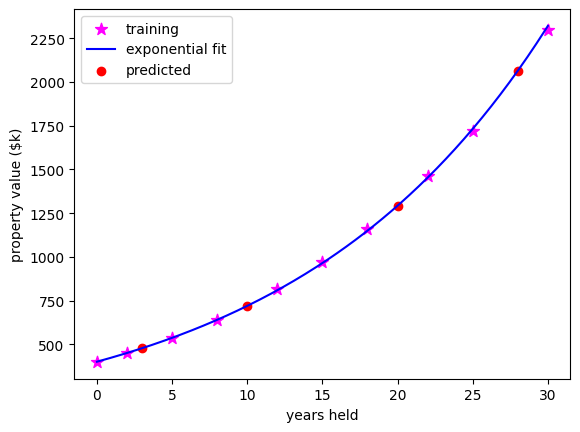

In [6]:
year_grid = np.linspace(df.years.min(), df.years.max(), 200)
curve = a * np.exp(r * year_grid)

plt.scatter(df.years, df.value, color='magenta', marker='*', s=80, label='training')
plt.plot(year_grid, curve, color='blue', label='exponential fit')
plt.scatter(tst.years, tst.value, color='red', label='predicted')
plt.xlabel('years held')
plt.ylabel('property value ($k)')
plt.legend()